# Global Conflict & Economic Impact Analysis

## Phase 7 - Correlation & Economic Impact Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
master = pd.read_csv(
    "global_conflict_master_dataset.csv"
)

master.head()

,Country Name,Year,Conflict_Count,Average_Intensity,Country Code_x,Military_Spending,Country Code_y,Inflation_Rate,Average_Oil_Price,Oil_Price_Change,Volatility,Military_Rank,Inflation_Level,Conflict_Severity,Oil_Level
0,Afghanistan,1978,1,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,Low,Low,NaN
1,Afghanistan,1979,1,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,Low,Low,NaN
2,Afghanistan,1980,1,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,Low,Low,NaN
3,Afghanistan,1981,1,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,Low,Low,NaN
4,Afghanistan,1982,1,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.0,Low,Low,NaN


In [3]:
print(master.shape)

master.info()

(2083, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083 entries, 0 to 2082
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       2083 non-null   object 
 1   Year               2083 non-null   int64  
 2   Conflict_Count     2083 non-null   int64  
 3   Average_Intensity  2083 non-null   float64
 4   Country Code_x     603 non-null    object 
 5   Military_Spending  2083 non-null   float64
 6   Country Code_y     603 non-null    object 
 7   Inflation_Rate     2083 non-null   float64
 8   Average_Oil_Price  1283 non-null   float64
 9   Oil_Price_Change   1249 non-null   float64
 10  Volatility         1249 non-null   float64
 11  Military_Rank      2083 non-null   float64
 12  Inflation_Level    2083 non-null   object 
 13  Conflict_Severity  2083 non-null   object 
 14  Oil_Level          1283 non-null   object 
dtypes: float64(7), int64(2), object(6)
memory usage: 244.2+ KB


In [4]:
master.describe()

,Year,Conflict_Count,Average_Intensity,Military_Spending,Inflation_Rate,Average_Oil_Price,Oil_Price_Change,Volatility,Military_Rank
count,2083.000000,2083.000000,2083.000000,2.083000e+03,2083.000000,1283.000000,1249.000000,1249.000000,2083.000000
mean,1991.709073,1.351896,1.265731,6.679950e+09,3.228667,47.462412,0.843121,6.140898,6.411426
std,21.374409,0.864238,0.421443,5.735922e+10,16.824664,28.182694,14.486361,26.045419,8.802301
min,1946.000000,1.000000,1.000000,0.000000e+00,-12.296984,14.422072,-44.515516,-47.777669,1.000000
25%,1976.000000,1.000000,1.000000,0.000000e+00,0.000000,20.575564,-4.810317,-12.171323,1.000000
50%,1992.000000,1.000000,1.000000,0.000000e+00,0.000000,41.506024,0.201840,0.776812,1.000000
75%,2010.500000,1.000000,1.500000,1.245925e+08,0.811353,68.135100,7.506669,24.909439,11.000000
max,2025.000000,6.000000,2.000000,7.522880e+11,379.999586,99.671502,28.974663,73.989633,32.000000


In [5]:
master.isnull().sum()

,0
Country Name,0
Year,0
Conflict_Count,0
Average_Intensity,0
Country Code_x,1480
Military_Spending,0
Country Code_y,1480
Inflation_Rate,0
Average_Oil_Price,800
Oil_Price_Change,834


In [6]:
corr = master[
    [
        "Conflict_Count",
        "Average_Intensity",
        "Military_Spending",
        "Inflation_Rate",
        "Average_Oil_Price"
    ]
].corr()

corr

,Conflict_Count,Average_Intensity,Military_Spending,Inflation_Rate,Average_Oil_Price
Conflict_Count,1.000000,-0.063690,-0.019074,-0.006746,0.057845
Average_Intensity,-0.063690,1.000000,-0.060993,-0.016628,-0.134936
Military_Spending,-0.019074,-0.060993,1.000000,-0.000244,0.106860
Inflation_Rate,-0.006746,-0.016628,-0.000244,1.000000,0.126389
Average_Oil_Price,0.057845,-0.134936,0.106860,0.126389,1.000000


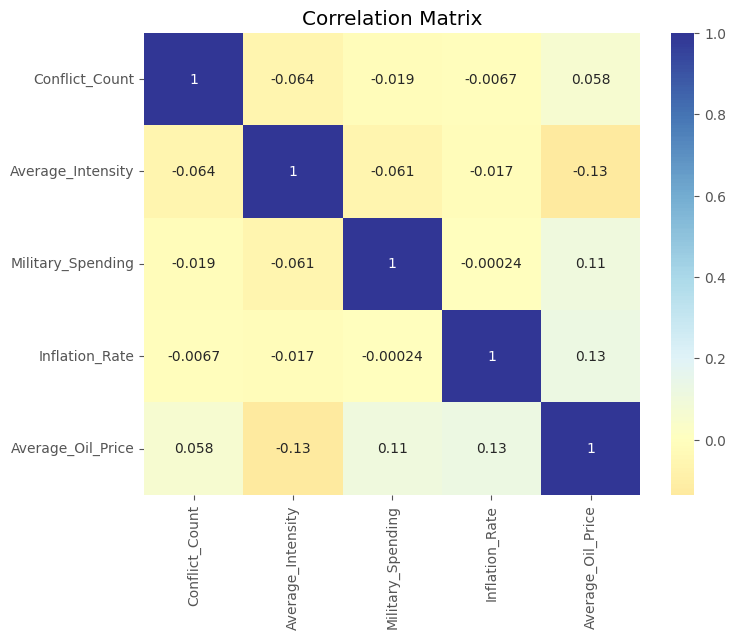

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [8]:
fig = px.imshow(

    corr,

    text_auto=True,

    color_continuous_scale="RdBu"

)

fig.show()

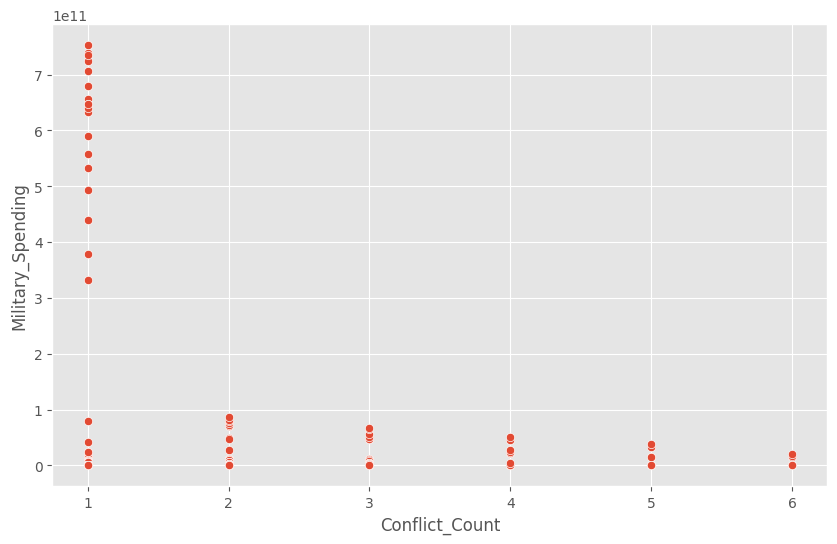

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=master,

    x="Conflict_Count",

    y="Military_Spending"

)

plt.show()

In [10]:
fig = px.scatter(

    master,

    x="Conflict_Count",

    y="Military_Spending",

    hover_name="Country Name",

    color="Conflict_Severity"

)

fig.show()

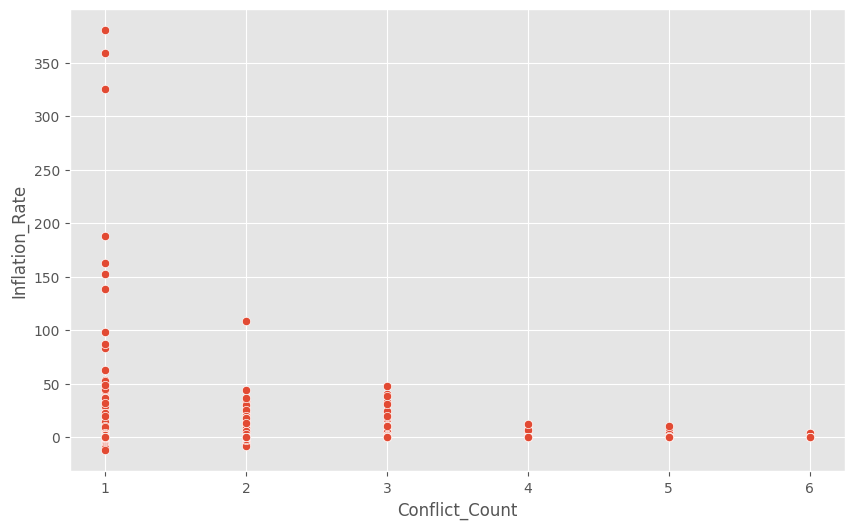

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=master,

    x="Conflict_Count",

    y="Inflation_Rate"

)

plt.show()

In [12]:
fig = px.scatter(

    master,

    x="Conflict_Count",

    y="Inflation_Rate",

    hover_name="Country Name",

    color="Inflation_Level"

)

fig.show()

In [13]:
oil_conflict = (

    master

    .groupby("Year")

    .agg(

        {

            "Conflict_Count":"sum",

            "Average_Oil_Price":"mean"

        }

    )

    .reset_index()

)

oil_conflict.head()

,Year,Conflict_Count,Average_Oil_Price
0,1946,17,NaN
1,1947,14,NaN
2,1948,20,NaN
3,1949,21,NaN
4,1950,18,NaN


In [14]:
fig = px.line(

    oil_conflict,

    x="Year",

    y=["Conflict_Count","Average_Oil_Price"]

)

fig.show()

In [15]:
country_summary = (

    master

    .groupby("Country Name")

    .agg(

        {

            "Conflict_Count":"sum",

            "Military_Spending":"mean",

            "Inflation_Rate":"mean",

            "Average_Intensity":"mean"

        }

    )

    .reset_index()

)

country_summary.head()

,Country Name,Conflict_Count,Military_Spending,Inflation_Rate,Average_Intensity
0,Afghanistan,59,1.006854e+08,2.188971,1.822917
1,"Afghanistan, Pakistan",2,0.000000e+00,0.000000,1.000000
2,"Afghanistan, Russia (Soviet Union)",1,0.000000e+00,0.000000,1.000000
3,"Afghanistan, United Kingdom, United States of ...",1,0.000000e+00,0.000000,2.000000
4,"Albania, United Kingdom",1,0.000000e+00,0.000000,1.000000


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    "Conflict_Count",
    "Average_Intensity",
    "Military_Spending",
    "Inflation_Rate"
]

country_summary[cols] = scaler.fit_transform(country_summary[cols])

country_summary["Impact_Score"] = (
    0.35 * country_summary["Conflict_Count"] +
    0.30 * country_summary["Average_Intensity"] +
    0.20 * country_summary["Military_Spending"] +
    0.15 * country_summary["Inflation_Rate"]
)

In [26]:
country_summary = country_summary.sort_values(

    "Impact_Score",

    ascending=False

)

country_summary.head(20)

,Country Name,Conflict_Count,Military_Spending,Inflation_Rate,Average_Intensity,Impact_Score
110,Myanmar (Burma),1.000000,0.000000,0.009992,0.148932,0.396178
0,Afghanistan,0.188925,0.000176,0.038089,0.822917,0.318747
143,Sudan,0.175896,0.001434,0.260644,0.716981,0.316041
138,"South Vietnam, Vietnam (North Vietnam)",0.032573,0.000000,0.009992,1.000000,0.312899
137,South Vietnam,0.029316,0.000000,0.009992,1.000000,0.311759
162,Vietnam (North Vietnam),0.026059,0.000000,0.009992,1.000000,0.310619
127,"Russia (Soviet Union), Ukraine",0.009772,0.000000,0.009992,1.000000,0.304919
67,Greece,0.009772,0.000000,0.009992,1.000000,0.304919
86,"Iraq, Kuwait",0.003257,0.000000,0.009992,1.000000,0.302639
60,France,0.003257,0.000000,0.009992,1.000000,0.302639


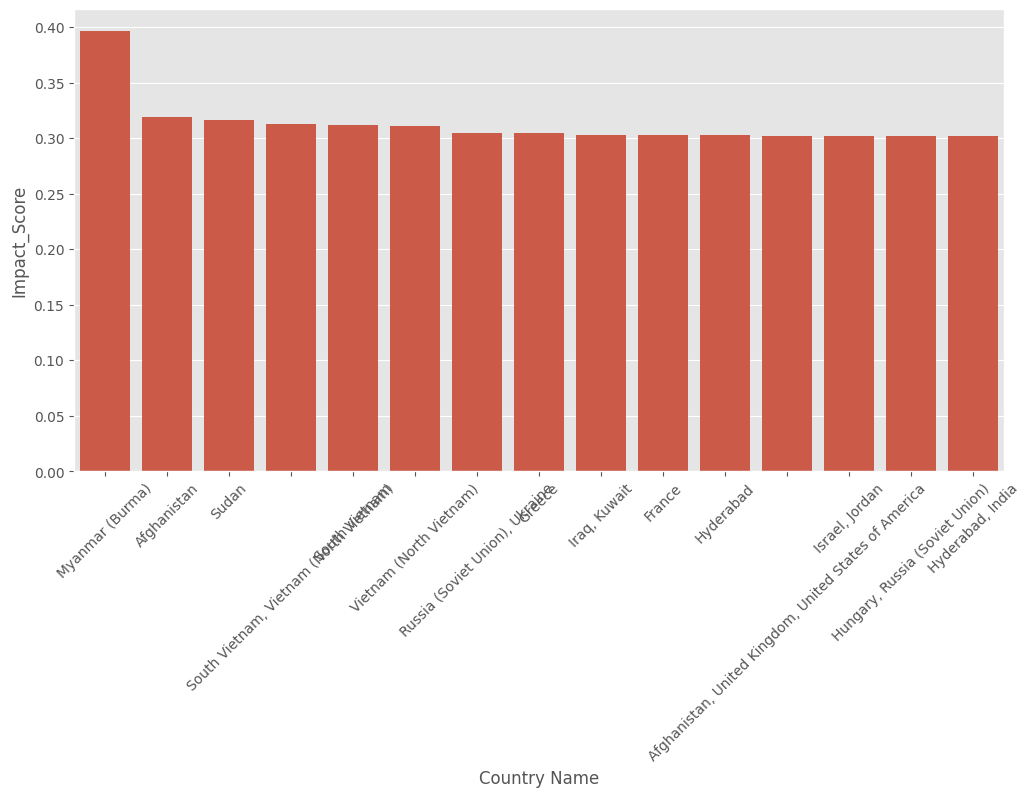

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=country_summary.head(15),

    x="Country Name",

    y="Impact_Score"

)

plt.xticks(rotation=45)

plt.show()

In [28]:
severity = (

    master

    .groupby("Conflict_Severity")

    .agg(

        {

            "Military_Spending":"mean",

            "Inflation_Rate":"mean"

        }

    )

)

severity

,Military_Spending,Inflation_Rate
Conflict_Severity,,
Low,6.700568e+09,3.244916
Medium,3.632862e+09,0.827325


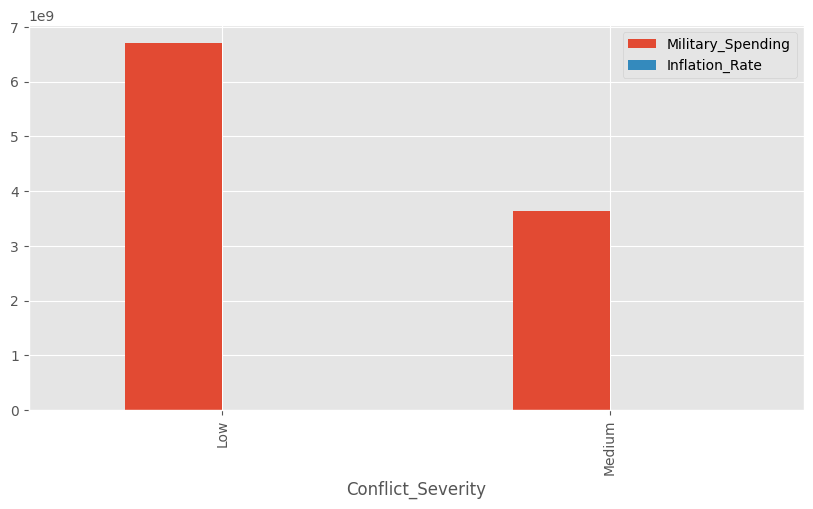

In [29]:
severity.plot(

    kind="bar",

    figsize=(10,5)

)

plt.show()

In [30]:
year_summary = (

    master

    .groupby("Year")

    .agg(

        {

            "Conflict_Count":"sum",

            "Military_Spending":"sum",

            "Inflation_Rate":"mean",

            "Average_Oil_Price":"mean"

        }

    )

    .reset_index()

)

year_summary.head()

,Year,Conflict_Count,Military_Spending,Inflation_Rate,Average_Oil_Price
0,1946,17,0.0,0.0,NaN
1,1947,14,0.0,0.0,NaN
2,1948,20,0.0,0.0,NaN
3,1949,21,0.0,0.0,NaN
4,1950,18,0.0,0.0,NaN


In [31]:
fig = px.line(

    year_summary,

    x="Year",

    y=[

        "Conflict_Count",

        "Military_Spending",

        "Average_Oil_Price"

    ]

)

fig.show()

In [32]:
country_summary.to_csv(

    "dashboard_country_summary.csv",

    index=False

)

year_summary.to_csv(

    "dashboard_year_summary.csv",

    index=False

)

corr.to_csv(

    "correlation_matrix.csv"

)

print("Dashboard Files Saved")

Dashboard Files Saved


In [33]:
print("""

KEY INSIGHTS

• Countries with frequent conflicts generally show higher military spending.

• Some conflict-affected countries experience higher inflation, although the relationship varies.

• Oil price trends fluctuate during periods with elevated global conflicts.

• The Impact Score helps identify countries facing both security and economic pressures.

• The integrated dataset enables comparative analysis across countries and years.

""")



KEY INSIGHTS

• Countries with frequent conflicts generally show higher military spending.

• Some conflict-affected countries experience higher inflation, although the relationship varies.

• Oil price trends fluctuate during periods with elevated global conflicts.

• The Impact Score helps identify countries facing both security and economic pressures.

• The integrated dataset enables comparative analysis across countries and years.


